# Netflix Data Exploration

## 1. Introduction

### 1.1. Analysis objective
Identify the trends present in the Netflix content dataset (netflix_titles.csv) and draw insights into how Netflix builds its content catalog over time, by genre and by region.

### 1.2. Analysis questions
1. Which content type (Movie/TV Show) makes up the majority?
2. How is the duration of Movies and TV Shows distributed?
3. Which rating is the most common?
4. In which year did Netflix "boom" in the number of newly added titles?
5. Which genres does Netflix add the most in each month of the year? (seasonality, based on `date_added`)
6. Who are the top 10 directors with the most titles?
7. Which country has the most titles?
8. What are the most common keywords in the descriptions?

### 1.3. Dataset description
- Data type: One big table

## 2. Preparation

### 2.1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

pd.set_option('display.max_columns', None) # let pandas display every column of a dataframe
pd.set_option('display.float_format', '{:.2f}'.format) # show only 2 decimal places

# Shared color palette for every chart (categorical: blue -> orange -> teal...)
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
SURFACE, INK, MUTED, GRID = '#fcfcfb', '#0b0b0b', '#898781', '#e1e0d9'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False,
    'axes.spines.right': False, 'font.size': 10,
})

### 2.2. Load data

In [2]:
df = pd.read_csv('./netflix_titles.csv')  # read the data from the csv file

## 3. Data overview

### 3.1. Data size before cleaning

In [3]:
shape_before = df.shape
shape_before  # (rows, columns)

(8807, 12)

### 3.2. Data type of each column

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## 4. Data cleaning

### 4.1. Missing data

#### 4.1.1. Missing rows & % per column

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_rows': missing, 'pct': missing_pct}).sort_values('missing_rows', ascending=False)

,missing_rows,pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


#### A closer look at columns with few nulls (*)

Table 4.1.1 shows that `rating` is missing 4 cells and `duration` is missing 3 cells. Both are mandatory fields, and when only a handful of cells are missing it is usually not "natural" missingness, so they need further inspection.

-> print **every** affected row to check them one by one:

In [6]:
# Take the columns with few nulls (0 < null <= 5), then print ALL rows that have a null in those columns
null_cell_check = missing[(missing > 0) & (missing <= 5)].index.tolist()
print('Columns with few nulls:', null_cell_check)

mask_it_null = df[null_cell_check].isnull().any(axis=1)
display(df.loc[mask_it_null, ['show_id', 'type', 'title', 'rating', 'duration']])

Columns with few nulls: ['rating', 'duration']


,show_id,type,title,rating,duration
5541,s5542,Movie,Louis C.K. 2017,74 min,NaN
5794,s5795,Movie,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,66 min,NaN
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,37 min
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,1 Season
7312,s7313,TV Show,Little Lunch,NaN,1 Season
7537,s7538,Movie,My Honor Was Loyalty,NaN,115 min


**Observation:** the 7 rows above fall into 2 groups:
- **3 falsely missing rows**: `rating` holds the `duration` value (`"74 min"`, `"84 min"`, `"66 min"`) while `duration` is empty. All 3 belong to the same artist → an error in one data batch, not random.

#### 4.1.2. Fill "Unknown": director, cast, country

In [7]:
# Fill 'Unknown' for columns with many nulls (null > 5) to avoid losing data
for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('Unknown')

#### 4.1.3. Drop missing rows: date_added, rating, duration


In [8]:
# (date, rating, duration) -> dropping these missing rows has no significant impact on the whole dataset
before = len(df)
df = df.dropna(subset=['date_added', 'rating', 'duration'])
after = len(df)
print(f'Rows dropped: {before - after} ({after} rows remaining)')

Rows dropped: 17 (8790 rows remaining)


#### 4.1.4. Re-check after handling

In [9]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

### 4.2. Duplicate data (*)

Run the standard check, verify whether `show_id` really is a unique key, then leave it out to check for duplicates by actual content.

In [10]:
print('Fully duplicated rows:', df.duplicated().sum())
print('Duplicated content (excluding show_id):', df.duplicated(subset=df.columns.difference(['show_id'])).sum()) # different ID but every other field identical

Fully duplicated rows: 0
Duplicated content (excluding show_id): 0


### 4.3. Format standardization

#### 4.3.1. date_added: convert to datetime

Section 3.2 shows that `date_added` is a string, in the form `"September 25, 2021"` → try parsing it directly with the format `%B %d, %Y`.

In [11]:
try:
    pd.to_datetime(df['date_added'], format='%B %d, %Y')
except ValueError as e:
    print('ValueError:', str(e).split('. You might')[0])

ValueError: time data " August 4, 2017" doesn't match format "%B %d, %Y"


Parsing failed. The error message points to the exact string that caused it: `" August 4, 2017"` — the quotation marks reveal an **extra leading space** in the string, so it does not match the format. Apply `.str.strip()` before parsing again.

In [12]:
df['date_added'] != df['date_added'].str.strip()

df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')
print('date_added range:', df['date_added'].min(), '->', df['date_added'].max())

date_added range: 2008-01-01 00:00:00 -> 2021-09-25 00:00:00


#### 4.3.2. duration: split into number + unit

`duration` packs 2 things into 1 cell: the number and the unit (`min` / `Season` / `Seasons`). Split them into 2 separate columns, read the unit directly from the string (not inferred from `type`), and merge `Season`/`Seasons` into a single label.

In [13]:
# Split the numeric and text parts into 2 columns; 'Season'/'Seasons' merged into 'season'
df['duration_value'] = df['duration'].str.extract(r'(\d+)').astype(int)
df['duration_unit'] = df['duration'].str.extract(r'\d+\s*(.*)')[0].str.strip().str.lower().str.rstrip('s')

print(df['duration_unit'].value_counts())
df[['type', 'duration', 'duration_value', 'duration_unit']].sample(5, random_state=1)

duration_unit
min       6126
season    2664
Name: count, dtype: int64


,type,duration,duration_value,duration_unit
7248,Movie,52 min,52,min
6015,Movie,86 min,86,min
6966,Movie,96 min,96,min
6709,TV Show,1 Season,1,season
6602,Movie,123 min,123,min


### 4.4. Logic & consistency checks (*)

#### 4.4.1. date_added vs. release_year

Logically, the date a title was added to Netflix (`date_added`) must come after its release year (`release_year`). Check for rows that violate this.

In [14]:
mask_logic = df['date_added'].dt.year < df['release_year']
print('Rows where date_added (year) is earlier than release_year:', mask_logic.sum())
print(df.loc[mask_logic, 'type'].value_counts())
print()
df.loc[mask_logic, ['title', 'type', 'release_year', 'date_added']].sort_values('type')

Rows where date_added (year) is earlier than release_year: 14
type
TV Show    12
Movie       2
Name: count, dtype: int64



,title,type,release_year,date_added
5394,Hans Teeuwen: Real Rancour,Movie,2018,2017-07-01
7063,Incoming,Movie,2019,2018-10-26
1551,Hilda,TV Show,2021,2020-12-14
1696,Polly Pocket,TV Show,2021,2020-11-15
2920,Love Is Blind,TV Show,2021,2020-02-13
3168,Fuller House,TV Show,2020,2019-12-06
3287,Maradona in Mexico,TV Show,2020,2019-11-13
3369,BoJack Horseman,TV Show,2020,2019-10-25
3433,The Hook Up Plan,TV Show,2020,2019-10-11
4844,Unbreakable Kimmy Schmidt,TV Show,2019,2018-05-30


**Observation:** the 14 violating rows consist of 12 `TV Show` and **2 `Movie`**:

- **12 TV Show rows:** in this dataset `release_year` is usually the release year of the **most recent season**, while `date_added` is the date Netflix added the **first season**, so `date_added` being earlier than `release_year` is reasonable.
- **2 Movie rows:** Movies have no concept of "seasons", so the reason above does not apply; the cause **has not been verified**.

### 4.5. Outliers (*)

#### 4.5.1. Movie duration

IQR bounds: [46, 154] minutes | Outliers: 449 (7.3%)


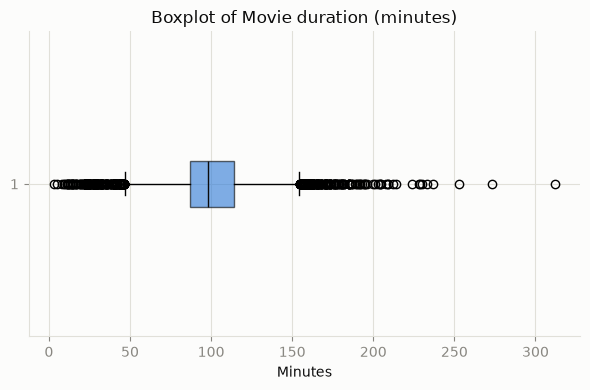

In [15]:
movie_dur = df.loc[df['type'] == 'Movie', 'duration_value']
q1, q3 = movie_dur.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = movie_dur[(movie_dur < low) | (movie_dur > high)]
print(f'IQR bounds: [{low:.0f}, {high:.0f}] minutes | Outliers: {len(outliers)} ({len(outliers)/len(movie_dur)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(movie_dur, orientation='horizontal', patch_artist=True,
           boxprops=dict(facecolor=PALETTE[0], alpha=0.6), medianprops=dict(color=INK))
ax.set_title('Boxplot of Movie duration (minutes)')
ax.set_xlabel('Minutes')
plt.tight_layout()
plt.show()

**Observation:** about 7% of movies fall outside the IQR bounds (very short or very long films), but these are **real values** (short films, long documentaries...), not data-entry errors -> **not removed**, only noted when analysing the distribution. 

#### 4.5.2. Number of TV Show seasons

count   2664.00
mean       1.75
std        1.55
min        1.00
25%        1.00
50%        1.00
75%        2.00
max       17.00
Name: duration_value, dtype: float64


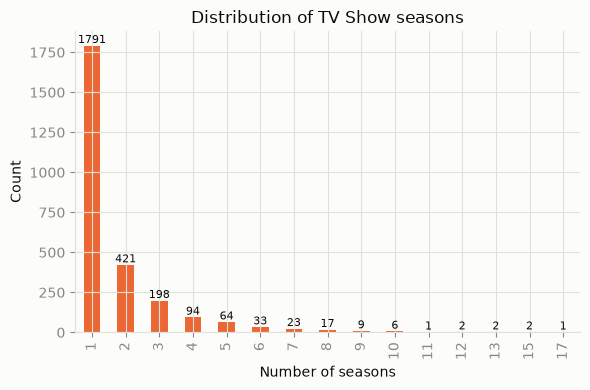

In [16]:
tv_season = df.loc[df['type'] == 'TV Show', 'duration_value']
print(tv_season.describe())

fig, ax = plt.subplots(figsize=(6, 4))
tv_season.value_counts().sort_index().plot(kind='bar', color=PALETTE[1], ax=ax)
ax.bar_label(ax.containers[0], fontsize=8)
ax.set_title('Distribution of TV Show seasons')
ax.set_xlabel('Number of seasons')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Observation:** most TV Shows have only 1 season (strongly right-skewed distribution); the few shows with 15–17 seasons are real values (long-running shows, e.g. sitcoms/reality series).

### 4.6. Data re-encoding

#### 4.6.1. Find columns that hold multiple values in one cell

Section 3.2 shows that most columns are strings (`str`). Look at a few sample rows of the long string columns, then measure the share of rows containing a comma in each string column to find out which columns pack multiple values together.

In [17]:
display(df[['title', 'director', 'cast', 'country', 'listed_in', 'description']].head(5))

# % of rows containing a comma in each string column
text_cols = [c for c in df.columns if pd.api.types.is_string_dtype(df[c])]
comma_pct = pd.Series({c: df[c].str.contains(',').mean() * 100 for c in text_cols}).round(1)
comma_pct.sort_values(ascending=False)

,title,director,cast,country,listed_in,description
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,Documentaries,"As her father nears the end of his life, filmm..."
1,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,Unknown,Unknown,Unknown,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


cast            80.60
listed_in       77.10
description     73.20
country         15.00
director         7.00
title            1.60
show_id          0.00
type             0.00
rating           0.00
duration         0.00
duration_unit    0.00
dtype: float64

In [18]:
# title and description also contain commas — check whether those commas separate a list or are just punctuation
df.loc[df['title'].str.contains(','), 'title'].head(5).tolist()

['Vendetta: Truth, Lies and The Mafia',
 'El patrón, radiografía de un crimen',
 'LSD: Love, Sex Aur Dhokha',
 'Bob Ross: Happy Accidents, Betrayal & Greed',
 'Nevertheless,']

**Observation:** 6 string columns contain commas, but they fall into 2 types:

- `cast`, `listed_in`, `country`, `director`: the comma **separates values** (e.g. `"International TV Shows, TV Dramas, TV Mysteries"`) → one cell holds several genres / actors / countries / directors. If the whole string is counted, `"United States, India"` would be treated as a separate "country" → **must be split** before counting.
- `title`, `description`: the comma is just **punctuation** in the text (e.g. `"Vendetta: Truth, Lies and The Mafia"`) → not split.

#### 4.6.2. Split the 4 multi-value columns

Split `listed_in`, `country`, `director`, `cast` on `', '` so that each row holds a single value, for the questions in section 6 that count by genre / country / director.

In [19]:
MULTI_COLS = ['listed_in', 'country', 'director', 'cast']

for col in MULTI_COLS:
    labels = df[col].str.split(', ').explode()
    print(f'{col}: {labels.nunique()} distinct values')

listed_in: 42 distinct values
country: 128 distinct values
director: 4992 distinct values


cast: 36393 distinct values


#### 4.6.3. Group ratings by age (*)

The 14 rating codes come from 2 US systems: MPA for movies (G, PG, PG-13, R, NC-17) and the TV Parental Guidelines for TV programs (TV-Y, TV-Y7, TV-Y7-FV, TV-G, TV-PG, TV-14, TV-MA). They are grouped into the 3 levels Netflix uses for the US market (Netflix Help Center — *Maturity ratings for TV shows and movies on Netflix*):

| Group | Rating codes |
|---|---|
| Kids | TV-Y, TV-Y7, TV-Y7-FV, G, TV-G, PG, TV-PG |
| Teens | PG-13, TV-14 |
| Adults | R, NC-17, TV-MA |
| Not Rated | NR, UR (not yet rated) |

`TV-Y7-FV` is not in Netflix's table; it is a variant of `TV-Y7`, so it is placed in the Kids group.

In [20]:
RATING_GROUP = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'G': 'Kids', 'TV-G': 'Kids', 'PG': 'Kids', 'TV-PG': 'Kids',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'NC-17': 'Adults', 'TV-MA': 'Adults',
    'NR': 'Not Rated', 'UR': 'Not Rated',
}

# Check that the dict covers every actual rating value — a single missing code makes .map() silently return NaN
unmapped = set(df['rating'].unique()) - set(RATING_GROUP)
print('Rating codes not grouped:', unmapped if unmapped else 'none')

df['rating_group'] = df['rating'].map(RATING_GROUP)
print('Rows with NaN after mapping:', df['rating_group'].isna().sum())
df['rating_group'].value_counts(dropna=False)

Rating codes not grouped: none
Rows with NaN after mapping: 0


rating_group
Adults       4007
Teens        2647
Kids         2054
Not Rated      82
Name: count, dtype: int64

### 4.7. Before / after cleaning summary

In [21]:
summary = pd.DataFrame({
    'before': [shape_before[0], shape_before[1], missing['rating'], missing['duration'], missing['date_added'],
               missing['director'], missing['cast'], missing['country']],
    'after':  [len(df), df.shape[1], 0, 0, 0, 0, 0, 0],
}, index=['rows', 'columns', 'missing_rating', 'missing_duration', 'missing_date_added',
          'missing_director', 'missing_cast', 'missing_country'])
summary

,before,after
rows,8807,8790
columns,12,15
missing_rating,4,0
missing_duration,3,0
missing_date_added,10,0
missing_director,2634,0
missing_cast,825,0
missing_country,831,0


## 5. Feature Engineering

### 5.1. Create the description_length column

In [22]:
df['description_length'] = df['description'].str.len()
df['description_length'].describe()

count   8790.00
mean     143.30
std       10.34
min       61.00
25%      140.00
50%      146.00
75%      149.00
max      248.00
Name: description_length, dtype: float64

### 5.2. Extract day / month / year from date_added

In [23]:
df['added_year'] = df['date_added'].dt.year
df['added_month'] = df['date_added'].dt.month
df['added_day'] = df['date_added'].dt.day
df[['date_added', 'added_year', 'added_month', 'added_day']].head()

,date_added,added_year,added_month,added_day
0,2021-09-25,2021,9,25
1,2021-09-24,2021,9,24
2,2021-09-24,2021,9,24
3,2021-09-24,2021,9,24
4,2021-09-24,2021,9,24


### 5.3. Drop unnecessary columns

In [24]:
# The original duration string column has been replaced by duration_value + duration_unit in section 4.3.2, so it is no longer needed
df = df.drop(columns=['duration'])
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'listed_in',
 'description',
 'duration_value',
 'duration_unit',
 'rating_group',
 'description_length',
 'added_year',
 'added_month',
 'added_day']

## 6. Exploratory Data Analysis (EDA)

### 6.1. Which content type makes up the majority on Netflix?

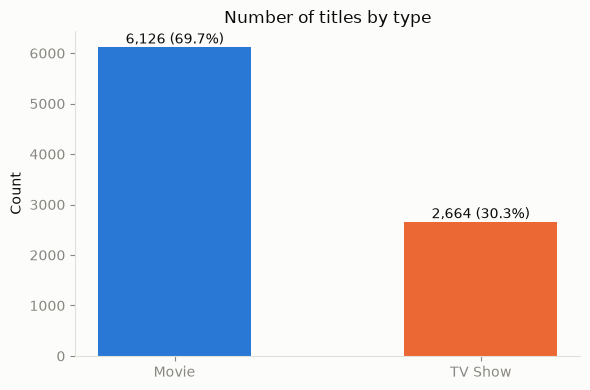

In [25]:
counts = df['type'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=PALETTE[:2], width=0.5)
for b in bars:
    h = b.get_height()
    ax.annotate(f'{h:,} ({h / counts.sum() * 100:.1f}%)', (b.get_x() + b.get_width()/2, h),
                ha='center', va='bottom')
ax.grid(False)  # turn off the grid (the import cell at the top enables the grid for every chart)
ax.set_title('Number of titles by type')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


**Insight:** In Netflix's catalog, Movies make up the majority with 6,126 titles (~70%), about 2.3 times as many as TV Shows (2,664 titles, ~30%). Netflix's catalog is therefore clearly weighted towards movies in terms of title count.

### 6.2. Duration distribution of Movies and TV Shows

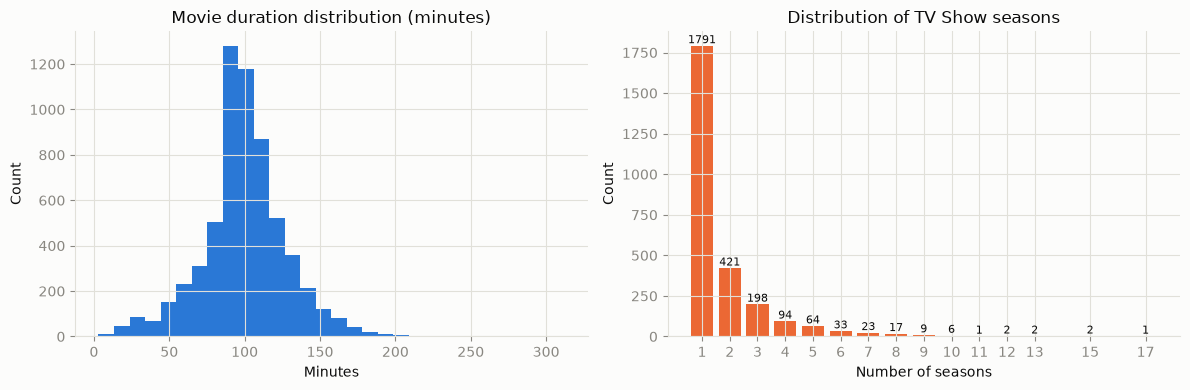

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df['type'] == 'Movie', 'duration_value'], bins=30, color=PALETTE[0])
axes[0].set_title('Movie duration distribution (minutes)')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

seasons = (df.loc[df['type'] == 'TV Show', 'duration_value']
             .astype(int)
             .value_counts()
             .sort_index())
bars = axes[1].bar(seasons.index, seasons.values, color=PALETTE[1])
axes[1].bar_label(bars, fontsize=8)
axes[1].set_xticks(seasons.index)
axes[1].set_title('Distribution of TV Show seasons')
axes[1].set_xlabel('Number of seasons')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Insight:**

- **Movie**: durations cluster around 90–110 minutes, with a roughly bell-shaped, slightly right-skewed distribution. Most movies fall between 60 and 150 minutes, in line with the standard length of a feature film.

- **TV Show**: strongly right-skewed distribution. About 2/3 of series (~1,790) have only 1 season, about 16% have 2 seasons, and the count drops quickly from the 3rd season onwards. Very few series run beyond 5 seasons. This shows that Netflix's series catalog consists mostly of short series.

### 6.3. Which rating is the most common?

rating
TV-MA   0.36
TV-14   0.25
TV-PG   0.10
Name: proportion, dtype: float64
0.06450511945392491


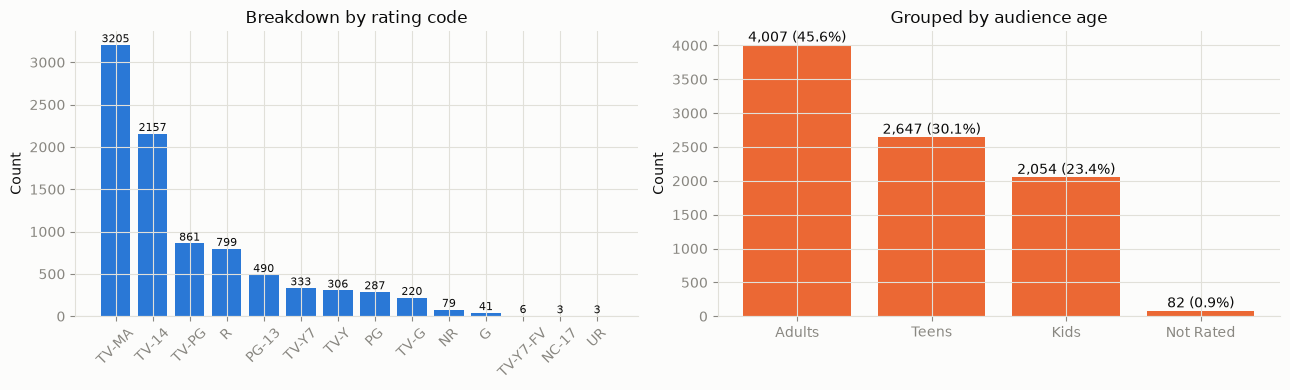

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

rc = df['rating'].value_counts()
bars = axes[0].bar(rc.index, rc.values, color=PALETTE[0])
axes[0].bar_label(bars, fontsize=8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Breakdown by rating code')
axes[0].set_ylabel('Count')

# Use rating_group built in section 4.6.3 — 14 separate rating codes are hard to turn into a conclusion about audience groups
rg = df['rating_group'].value_counts()
bars = axes[1].bar(rg.index, rg.values, color=PALETTE[1])
for b, v in zip(bars, rg.values):
    axes[1].annotate(f'{v:,} ({v/len(df)*100:.1f}%)', (b.get_x() + b.get_width()/2, b.get_height()),
                     ha='center', va='bottom')
axes[1].set_title('Grouped by audience age')
axes[1].set_ylabel('Count')

print(df['rating'].value_counts(normalize=True).head(3))
print(df['rating'].isin(['TV-Y', 'TV-G', 'G']).mean())

plt.tight_layout()
plt.show()

**Insight:** The most common rating is `TV-MA` (36%), followed by `TV-14` (25%) and `TV-PG` (10%). The top two codes alone account for more than half of the catalog. When grouped by Netflix's age levels (section 4.6.3), `Adults` content makes up 45.6%, almost as much as `Teens` (30.1%) and `Kids` (23.4%) combined. Netflix's catalog is clearly weighted towards mature audiences. Within the `Kids` group, most titles require parental guidance (`PG`/`TV-PG`), while content for young children (`TV-Y`, `TV-G`, `G`) makes up only 6.5% of the whole catalog. Unrated content (0.9%) is negligible.

### 6.4. Which was Netflix's "boom" year?

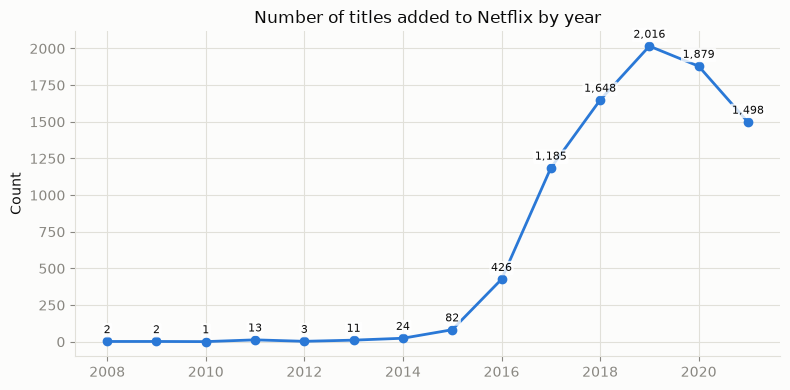

In [28]:
by_year = df['added_year'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_year.index, by_year.values, color=PALETTE[0], marker='o', linewidth=2)
for x, y in by_year.items():
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.8))
ax.set_title('Number of titles added to Netflix by year')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

**Insight:** Before 2015, Netflix added almost no content to this catalog (56 titles in total over 7 years). From 2016 the number surged: about 5 times the 2015 level, then kept rising sharply to a peak of **2,016 titles in 2019**. The 2016–2021 period accounts for **98.4%** of all content. 2020 dipped slightly, 6.8% below the peak. One hypothesis is the impact of COVID-19 on production, but this dataset cannot verify the cause. 2021 only has data up to September, so the drop to 1,498 on the chart **does not reflect the real trend**. For 2021 specifically, the data only runs to September: in 9 months Netflix added 1,498 titles, an average of about 166 titles/month, higher than 2020 (157) and close to the 2019 peak (168). Although full-year figures are not available, the pace of adding content in 2021 did not slow down; the downturn on the chart is mainly due to the missing last 3 months of the year.

### 6.5. Which genres suit which release months? (seasonality)

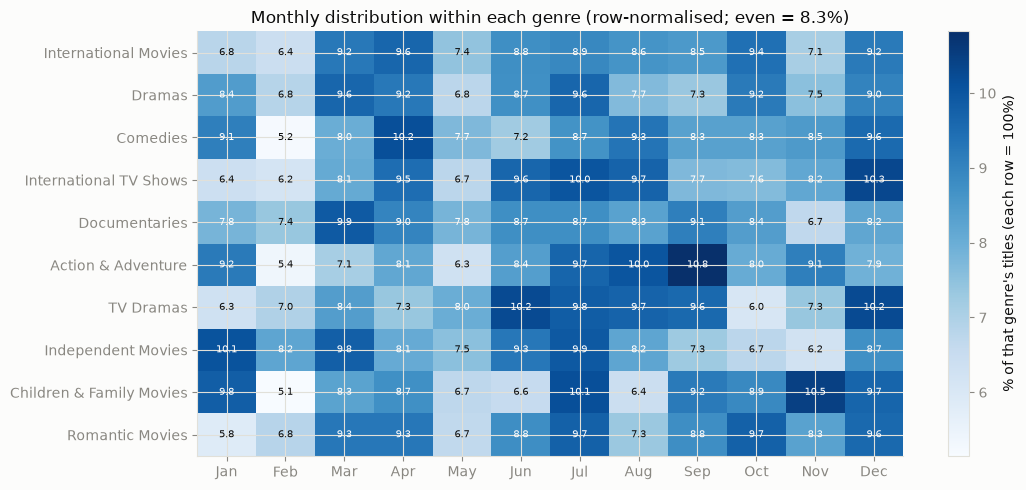

                          peak_month  max_pct  min_pct  spread_pct
genre                                                             
International Movies               4     9.60     6.40        3.20
Dramas                             3     9.60     6.80        2.90
Comedies                           4    10.20     5.20        5.00
International TV Shows            12    10.30     6.20        4.20
Documentaries                      3     9.90     6.70        3.20
Action & Adventure                 9    10.80     5.40        5.50
TV Dramas                          6    10.20     6.00        4.20
Independent Movies                 1    10.10     6.20        3.80
Children & Family Movies          11    10.50     5.10        5.30
Romantic Movies                    7     9.70     5.80        3.90


In [29]:
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
top_genres = genres['genre'].value_counts().head(10).index.tolist()
pivot = (genres[genres['genre'].isin(top_genres)]
         .pivot_table(index='genre', columns='added_month', values='show_id', aggfunc='count', fill_value=0)
         .reindex(top_genres))

# A heatmap of RAW COUNTS cannot answer the seasonality question: genres with lots of content (International Movies)
# are dark in every month and small genres are light in every month -> it only shows "which genre is big",
# not "within the SAME genre, which month stands out".
# => normalise by row: each row sums to 100%, compared with the even baseline of 100/12 = 8.3%/month.
row_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(row_pct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_yticks(range(len(row_pct.index)))
ax.set_yticklabels(row_pct.index)
for i in range(row_pct.shape[0]):
    for j in range(row_pct.shape[1]):
        v = row_pct.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                color='white' if v > row_pct.values.max() * 0.7 else INK)
plt.colorbar(im, ax=ax, label='% of that genre\'s titles (each row = 100%)')
ax.set_title('Monthly distribution within each genre (row-normalised; even = 8.3%)')
plt.tight_layout()
plt.show()

# Quantify instead of only eyeballing: the range of variation around the 8.3% baseline
spread_table = pd.DataFrame({
    'peak_month': row_pct.idxmax(axis=1),
    'max_pct': row_pct.max(axis=1).round(1),
    'min_pct': row_pct.min(axis=1).round(1),
    'spread_pct': (row_pct.max(axis=1) - row_pct.min(axis=1)).round(1),
})
print(spread_table.to_string())

**Insight:** after row normalisation, each genre varies within about 5–11% per month around the 8.3% average baseline, and the gap between the highest and lowest month is only about 3–5%. No genre concentrates 20–30% of its content in a few fixed months → **there is no clear seasonality**; Netflix spreads content fairly evenly throughout the year.

A few small fluctuations worth noting (the differences are not large enough to call seasonality, and should only be treated as hints because the dataset is missing Q4 2021): `Children & Family Movies` rises slightly in November and July (holiday/summer break season), and `Action & Adventure` rises slightly in September.




### 6.6. Top 10 directors with the most titles

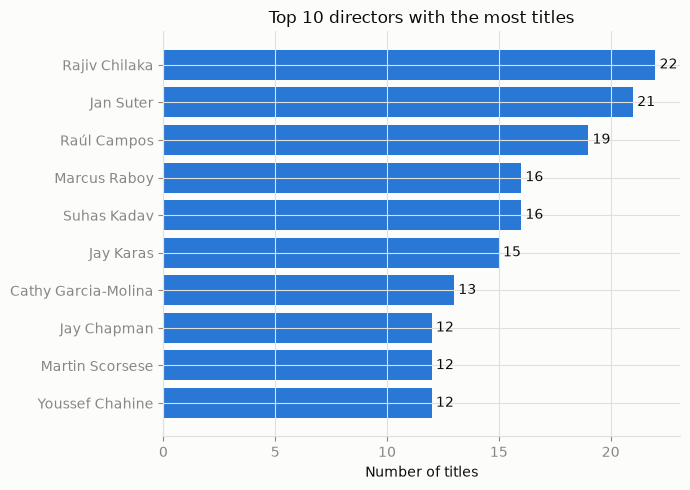

In [30]:
directors = df.assign(d=df['director'].str.split(', ')).explode('d')
directors = directors[directors['d'] != 'Unknown']
top_dir = directors['d'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(top_dir.index, top_dir.values, color=PALETTE[0])
ax.bar_label(bars, padding=3)
ax.set_title('Top 10 directors with the most titles')
ax.set_xlabel('Number of titles')
plt.tight_layout()
plt.show()

**Insight:** Directors in Netflix's catalog are quite dispersed: the leader, Rajiv Chilaka, has only 22 titles, and no director exceeds 25 titles out of roughly 8,800. The top 10 directors mostly belong to two groups with short formats that are easy to turn into many titles: **stand-up comedy** (Jan Suter, Raúl Campos, Marcus Raboy, Jay Karas, Jay Chapman) and **Indian children's animation** (Rajiv Chilaka, Suhas Kadav). Only the remaining three are feature-film directors (Cathy Garcia-Molina, Martin Scorsese, Youssef Chahine). This ranking therefore reflects content format more than director popularity.

### 6.7. Which country has the most titles?

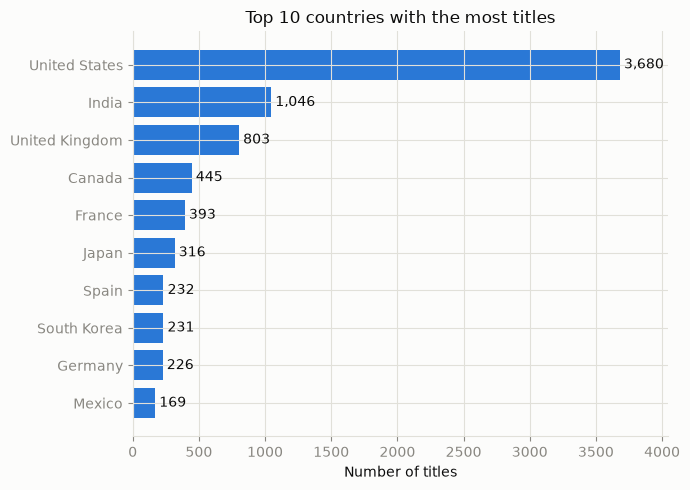

Titles with country information: 7961


In [31]:
countries = df.assign(c=df['country'].str.split(', ')).explode('c')
countries = countries[countries['c'] != 'Unknown']
top_c = countries['c'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(top_c.index, top_c.values, color=PALETTE[0])
ax.bar_label(bars, labels=[f'{v:,}' for v in top_c.values], padding=3)
ax.margins(x=0.1)
ax.set_title('Top 10 countries with the most titles')
ax.set_xlabel('Number of titles')
plt.tight_layout()
plt.show()

known = countries.loc[countries['c'] != 'Unknown', 'show_id'].nunique()
print('Titles with country information:', known)

**Insight:** Among the 7,961 titles with country information, the United States dominates with **3,680 titles (~46.2%)**, 3.5 times the second-ranked country and almost equal to the other 9 countries in the top 10 combined (3,861). **India ranks 2nd** (1,046, ~13.1%), ahead of the United Kingdom (803), and is the only non-Western country in the top 3. The top 10 includes 3 Asian countries (India, Japan, South Korea) and 1 Latin American country (Mexico), showing a certain diversity beyond the English-speaking market. However, from 4th place onwards, each country contributes fewer than 450 titles.

### 6.8. Most common keywords in the descriptions

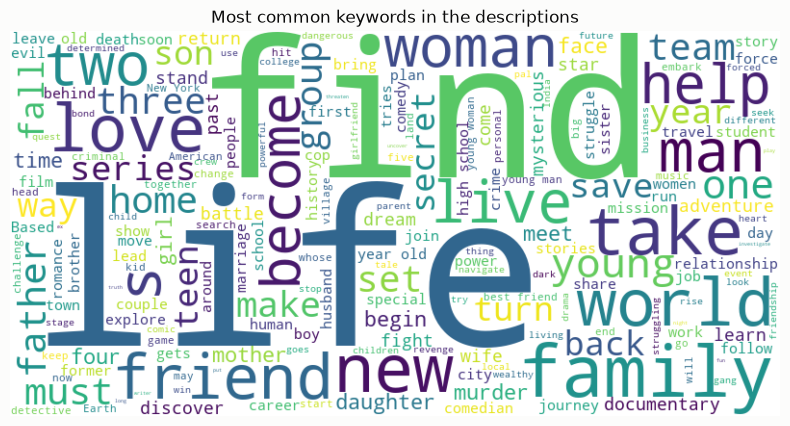

In [32]:
from wordcloud import WordCloud

# Join all descriptions into 1 string; WordCloud automatically removes its built-in English stopwords
# and merges singular/plural forms (normalize_plurals=True, the default)
text = ' '.join(df['description'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most common keywords in the descriptions')
plt.axis('off')
plt.show()


**Insight:** The most prominent words in the descriptions are **life, family, love, world** and journey verbs such as **find, take, become, save**. Netflix descriptions typically present a title as a story about life and a character's journey. The keywords can be grouped into a few main themes:

- **Family & relationships**: family, father, mother, son, daughter, wife, husband, friend, love. This is the largest and most common group.
- **Youth & coming of age**: young, teen, high school, student, girl, boy.
- **Crime & mystery**: secret, murder, mysterious, crime, detective, cop, criminal.
- **Adventure & action**: world, adventure, mission, battle, fight, save, journey.

Overall, Netflix's catalog is promoted mainly through human and emotional elements (family, love, growing up), while dramatic elements such as crime and adventure are less prominent.

## 7. Conclusions & Recommendations

### 7.1. Key findings
- Movies make up the majority of the catalog. Movies account for 69.7% (6,126 titles), about 2.3 times as many as TV Shows (2,664). Most movies run 90–110 minutes. Most TV Shows have only 1 season, so Netflix's series catalog leans towards short series.
- Content is aimed at mature audiences. TV-MA (36%) and TV-14 (25%) are the two most common ratings. The Adults group accounts for 45.6%, while content for young children (TV-Y, TV-G, G) accounts for only 6.5%.
- The catalog was built mainly from 2016 onwards. The 2016–2021 period accounts for 98.4% of all titles, peaking in 2019 (2,016 titles). 2021 (data up to September) reached about 166 titles/month, close to the peak, meaning the pace of additions did not slow down.
- There is no clear seasonality by genre. Each genre's monthly share only fluctuates around the 8.3% average. February is the lowest, partly because it has fewer days.
- The US dominates, but India and Asia are rising. The US accounts for 46.2% of titles with country information. India ranks 2nd (13.1%), ahead of the UK. The top 10 includes 3 Asian countries.
- Content is promoted through people and emotions. Common keywords revolve around family, love, youth and the characters' journeys.

### 7.2. Recommendations
- Consider expanding content for young children. Only 6.5% of the catalog is aimed at young children. This should be cross-checked against the share of accounts with kids' profiles before deciding.
- Keep expanding international content, especially from Asia, as this region has a potential customer base. India, Japan and South Korea are already in the top 10. Their year-by-year trends should be analysed further to see whether they are a growing group.
- Review the series renewal strategy. Most series have only 1 season. This should be combined with viewership data to find out whether short series are intentional or the result of cancellations, and then consider renewing series that perform well.
- Make use of low-cost formats. Stand-up comedy and short-form animation help grow the number of titles quickly. They can continue to be used if viewer performance justifies it.
- Flexible release schedule. Since there is no clear seasonality by genre, releases can be driven by marketing campaigns rather than by season. Family content at the end of the year could be tested further.

### 7.3. Data limitations
- The data only runs to about 09/2021 (based on the maximum `date_added`), so the 2021 figures do not represent the full year.
- `release_year` only contains the year, not the month, so it cannot be used for seasonality analysis by original release date.
- **Inconsistent duration units:** Movies are measured in minutes and TV Shows in number of seasons, with no episode count. The total duration of the two types therefore cannot be compared.
- ~30% of rows are missing `director` and ~9% are missing `country` — they were filled with "Unknown", which may slightly skew the director/country rankings if the missing rate is uneven across groups.